In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Variance around mean, sum of squared residuals

def find_means(y):

  y_mean = y.mean()
  nominator = 0
  n = len(y)

  for i in range(n):
    nominator += pow(y[i] - y_mean,2)

  ss_mean = nominator
  var_mean = ss_mean / n

  return y_mean, ss_mean, var_mean

In [3]:
# Fitting the line
# y = wx + b

def fit_line(x,y,n):

  x_mean = x.mean()
  y_mean = y.mean()
  sum_x_y = 0
  ss_x = 0

  for i in range(n):
    sum_x = x[i]-x_mean
    sum_x_y += sum_x * (y[i]-y_mean)
    ss_x += pow(sum_x, 2)

  w = sum_x_y / ss_x
  b = y_mean - w * x_mean

  return w, b

In [4]:
# Getting the predictions

def get_preds(x,w,b):

  pred_y = []

  for i in range(len(x)):
    pred_y.append(w * x[i] + b)

  return pred_y

In [5]:
# Calculating the SS(fit), loss

def calc_ss_fit(y, pred_y):

  ss_fit = 0

  for i in range(len(y)):
    ss_fit += pow((y[i] - pred_y[i]), 2)

  return ss_fit

In [6]:
# Calculating the R^2
def calc_r_2(ss_mean, ss_fit):
  r_2 = (ss_mean - ss_fit) / ss_mean

  return r_2

In [7]:
# Calculating the F value to show the significance of the R^2 value.
def calc_f(ss_mean, ss_fit,n):
  p_mean = 1 # just the mean
  p_fit = 2 # w and b


  F = ((ss_mean - ss_fit) / (p_fit - p_mean)) / (ss_fit / (n - p_fit))
  return F



In [8]:
# X = weights of the mices
# Y = sizes of the mices

y = np.array([1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3])
x = np.array([0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3])

In [9]:
# Finding the F value of the real data

n = len(y)

y_mean, ss_mean, var_mean = find_means(y)

w,b = fit_line(x,y,n)

y_pred = get_preds(x,w,b)

ss_fit = calc_ss_fit(y, y_pred) # Calculating the sum of the squared residuals of the fitted line.

real_r_2 = calc_r_2(ss_mean, ss_fit)
real_f_value = calc_f(ss_mean, ss_fit, n)

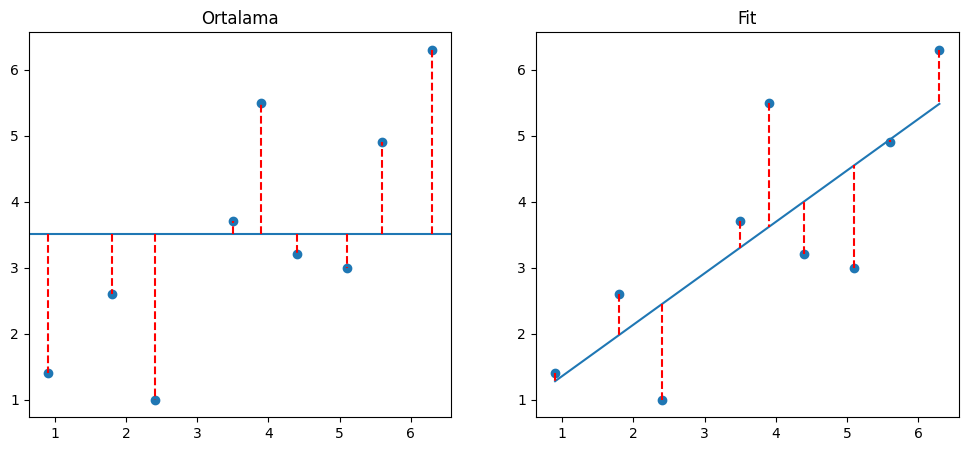

In [10]:
# Plotting the SS(mean) and SS(fit), R^2 = (SS(mean) - SS(fit)) / SS(mean)

plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.scatter(x, y)
plt.axhline(y_mean)
plt.vlines(x, y_mean, y, linestyles = 'dashed', color = 'red')
plt.title('Ortalama')

plt.subplot(1,2,2)
plt.scatter(x,y)
plt.plot(x,y_pred)
plt.vlines(x, y, y_pred, linestyles = 'dashed', color = 'red')
plt.title('Fit')

plt.show()

In [11]:
# Creating a simulation to find the P value

n_iter = 10000
f_arr = []
r_arr = []

for i in range(n_iter):
  y_random = np.random.normal(loc = y.mean(), scale = y.std(), size = x.shape)

  y_mean, ss_mean, var_mean = find_means(y_random) # Getting the means

  w, b = fit_line(x,y_random,n) # Fitting the line

  y_pred = get_preds(x, w, b) # Getting the predictions

  ss_fit = calc_ss_fit(y_random, y_pred)

  r_2 = calc_r_2(ss_mean, ss_fit)
  F = calc_f(ss_mean, ss_fit, n)

  f_arr.append(F)
  r_arr.append(r_2)

In [12]:
# Calculation of the P value.

p_value = np.mean(np.array(f_arr) >= real_f_value)

print(f"Calculated p value: {p_value}")

Calculated p value: 0.0117


In [13]:
print(f"max f: {float(np.max(f_arr)):.2f}, min f: {np.min(f_arr)}")

max f: 101.09, min f: 9.886185220756304e-08


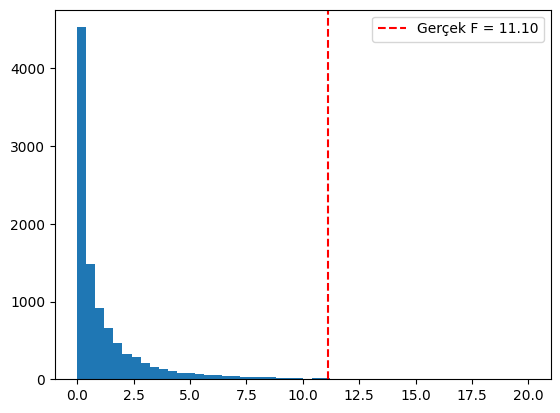

In [14]:
plt.hist(f_arr, bins = 50, range= (0,20))

plt.axvline(real_f_value, color ='red', linestyle = 'dashed', label=f'Gerçek F = {real_f_value:.2f}')
plt.legend()
plt.show()

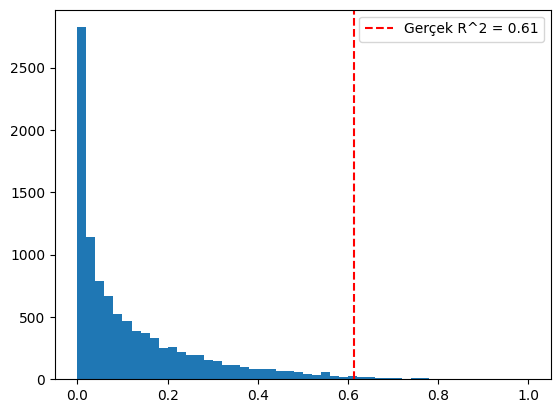

In [15]:
# Drawing a histogram with the r values.

plt.hist(r_arr, bins = 50, range = (0,1))
plt.axvline(real_r_2, color = 'red', linestyle = 'dashed', label= f'Gerçek R^2 = {real_r_2:.2f}')

plt.legend()
plt.show()

In [16]:
np.mean(np.array(r_arr) >= real_r_2)

np.float64(0.0117)

First, we fit a line to our data using the least squares method.

Then, we use the R² metric to show what percentage of the variance our fit explains, compared to the baseline (the mean). We found an R² of 0.61, which means that the weight explains 61% of the variance in size.

How do we know this R² value is meaningful? For a dataset with just two samples, the fit will always be a straight line from one point to the other, so R² will always be 100%. But this doesn't show that the weight actually does something. To solve this, we use the F-value and the p-value.

The F-value compares the variance explained per added parameter to the variance left unexplained per remaining data point:

F = ((SS(mean) − SS(fit)) / (p_fit − p_mean)) / (SS(fit) / (n − p_fit))

Our fit uses two parameters (w and b), and the baseline model uses one (the mean). Using SS(mean) and SS(fit), we calculate F = 11.10.

To check whether we could have gotten this result just by luck, we use the p-value. Our null hypothesis is that there is no relationship between the weights and the sizes of the mice.

To calculate the p-value, we run a simulation: we generate 10,000 random Y's independently of X, so there is no relationship between them, and compute the F-value for each. This gives us the distribution of F-values when the null hypothesis is true. We then place our real F-value on this histogram and calculate the fraction of simulated F-values that are greater than or equal to ours. This fraction is our p-value: 0.012.

Since 0.012 is below the common threshold of 0.05, we reject the null hypothesis: if there were no relationship, we would see an F-value this large only about 1.2% of the time.